In [1]:
# ============================================================================
# CELL 0: Install Library (If using VSCode)
# ============================================================================

# 1. Masuk Terminal
# 2. Buat .venv
    # python -m venv .venv
# 3. Aktifkan
    # .venv\Scripts\activate        # Windows
    # source .venv/bin/activate     # Mac/Linux
# 4. Install library
    # pip install -r requirements.txt
# 5. Run kode

In [2]:
# ============================================================================
# CELL 1: Initiate Kaggle Default libraries. (DO NOT TOUCH)
# ============================================================================

# Before so... you have to input link of the dataset first in the right panel of the screen
# To do that... go to "+ Add Input" > Type the input/dataset/notebooks which contains the dataset you want to train
# For this case, the dataset we need is a "work-from-home-employee-burnout-dataset" by Sonal Shinde

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import os

# Matikan peringatan yang tidak perlu agar notebook terlihat rapi
import warnings
warnings.filterwarnings('ignore')

# Cek lokasi file dataset dari Kaggle Input (Khusus lewat Kaggle)
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        file_path = os.path.join(dirname, filename)
        print("Dataset ditemukan di:", file_path)

In [3]:
# ============================================================================
# CELL 2.1: Load Data & Pre-EDA (Exploratory Data Analysis) Data Cleaning
# ============================================================================

# PERHATIAN: Ganti string di bawah ini dengan path file CSV-mu yang muncul dari print di atas atau input manual
DATASET_PATH = '..\wfh2_burnout_dataset.csv' # Sesuaikan path ini
df = pd.read_csv(DATASET_PATH)

# --- DROP 'user_id' DI AWAL SEBELUM EDA ---
# Menghapus kolom user_id segera setelah loading, sebelum EDA
# karena kolom ini hanyalah identitas responden dan tidak relevan untuk analisis.
df = df.drop(columns=['user_id'])

# Mengecek hasil cleaning awal
print("="*70)
print(" KOLOM 'user_id' TELAH DIHAPUS.")
print("="*70 + "\n")
print(df.info())
display(df.head(3))

 KOLOM 'user_id' TELAH DIHAPUS.

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   day_type           2000 non-null   str    
 1   work_hours         2000 non-null   float64
 2   screen_time_hours  2000 non-null   float64
 3   meetings_count     2000 non-null   int64  
 4   breaks_taken       2000 non-null   int64  
 5   after_hours_work   2000 non-null   int64  
 6   app_switches       2000 non-null   int64  
 7   sleep_hours        2000 non-null   float64
 8   task_completion    2000 non-null   float64
 9   isolation_index    2000 non-null   int64  
 10  fatigue_score      2000 non-null   float64
 11  burnout_score      2000 non-null   float64
 12  burnout_risk       2000 non-null   str    
dtypes: float64(6), int64(5), str(2)
memory usage: 203.3 KB
None


,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,app_switches,sleep_hours,task_completion,isolation_index,fatigue_score,burnout_score,burnout_risk
0,Weekday,7.74,5.99,3,7,0,50,7.50,74.80,4,3.51,17.23,Low
1,Weekday,8.48,7.23,3,5,0,63,7.31,86.36,4,5.15,24.01,Low
2,Weekend,8.39,7.14,1,5,0,27,6.73,89.23,8,7.85,51.46,Medium


In [4]:
# ============================================================================
# CELL 3.1: Data Overview - Missing Values & Duplicates & Class Distribution
# ============================================================================

print("--- CEK MISSING VALUES ---")
print(df.isnull().sum())

print("\n--- CEK DUPLIKAT ---")
print(f"Jumlah duplikat: {df.duplicated().sum()}")

print(f"\n--- BURNOUT RISK DISTRIBUTION ---")
print(df['burnout_risk'].value_counts())
print(f"\nPercentages:")
print(df['burnout_risk'].value_counts(normalize=True) * 100)

--- CEK MISSING VALUES ---
day_type             0
work_hours           0
screen_time_hours    0
meetings_count       0
breaks_taken         0
after_hours_work     0
app_switches         0
sleep_hours          0
task_completion      0
isolation_index      0
fatigue_score        0
burnout_score        0
burnout_risk         0
dtype: int64

--- CEK DUPLIKAT ---
Jumlah duplikat: 0

--- BURNOUT RISK DISTRIBUTION ---
burnout_risk
Low       1019
Medium     843
High       138
Name: count, dtype: int64

Percentages:
burnout_risk
Low       50.95
Medium    42.15
High       6.90
Name: proportion, dtype: float64


In [5]:
# ============================================================================
# CELL 3.2: Data Overview - Basic Info
# ============================================================================

print("--- TAMPILAN 5 DATA PERTAMA ---")
display(df.head())

print("\n--- INFORMASI TIPE DATA & JUMLAH BARIS ---")
display(df.info())

print("\n--- STATISTIK DESKRIPTIF ---")
display(df.describe())

--- TAMPILAN 5 DATA PERTAMA ---


,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,app_switches,sleep_hours,task_completion,isolation_index,fatigue_score,burnout_score,burnout_risk
0,Weekday,7.74,5.99,3,7,0,50,7.50,74.80,4,3.51,17.23,Low
1,Weekday,8.48,7.23,3,5,0,63,7.31,86.36,4,5.15,24.01,Low
2,Weekend,8.39,7.14,1,5,0,27,6.73,89.23,8,7.85,51.46,Medium
3,Weekday,12.48,12.23,4,1,1,89,6.55,64.47,5,10.00,55.50,Medium
4,Weekend,8.85,7.35,4,6,0,40,8.03,98.62,3,3.45,11.95,Low



--- INFORMASI TIPE DATA & JUMLAH BARIS ---
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   day_type           2000 non-null   str    
 1   work_hours         2000 non-null   float64
 2   screen_time_hours  2000 non-null   float64
 3   meetings_count     2000 non-null   int64  
 4   breaks_taken       2000 non-null   int64  
 5   after_hours_work   2000 non-null   int64  
 6   app_switches       2000 non-null   int64  
 7   sleep_hours        2000 non-null   float64
 8   task_completion    2000 non-null   float64
 9   isolation_index    2000 non-null   int64  
 10  fatigue_score      2000 non-null   float64
 11  burnout_score      2000 non-null   float64
 12  burnout_risk       2000 non-null   str    
dtypes: float64(6), int64(5), str(2)
memory usage: 203.3 KB


None


--- STATISTIK DESKRIPTIF ---


,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,app_switches,sleep_hours,task_completion,isolation_index,fatigue_score,burnout_score
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,8.955995,7.689495,3.728500,5.066000,0.15650,56.025500,6.894900,80.090670,4.875500,6.560825,35.656590
std,1.724214,1.983181,2.874877,1.762441,0.36342,23.702463,0.983893,12.708583,1.656011,2.218042,17.315039
min,4.730000,2.910000,0.000000,0.000000,0.00000,5.000000,3.580000,40.000000,3.000000,1.450000,6.060000
25%,7.750000,6.280000,2.000000,4.000000,0.00000,39.000000,6.320000,71.672500,3.000000,4.740000,21.005000
50%,8.535000,7.290000,3.000000,5.000000,0.00000,52.000000,7.080000,80.900000,5.000000,6.295000,32.330000
75%,9.980000,8.882500,5.000000,6.000000,0.00000,71.000000,7.570000,89.650000,6.000000,8.480000,47.475000
max,14.230000,13.980000,17.000000,11.000000,1.00000,152.000000,9.220000,100.000000,9.000000,10.000000,82.220000


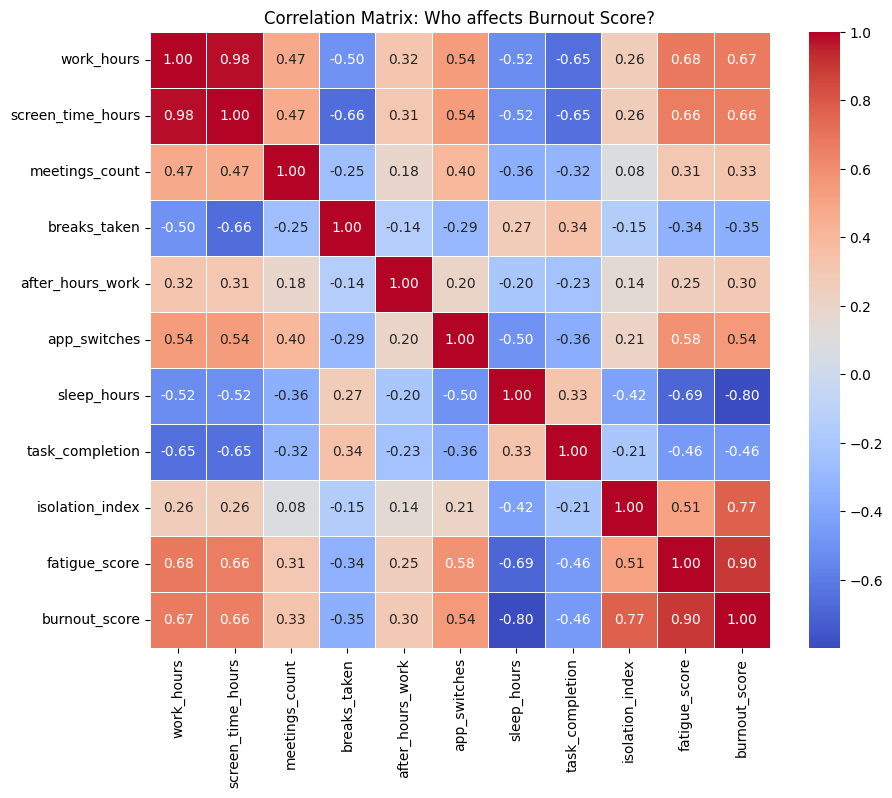

In [6]:
# ============================================================================
# CELL 4.1: Exploratory Data Analysis (EDA) - Correlation Matrix
# ============================================================================

# Memisahkan kolom numerik secara otomatis saja untuk visualisasi agar tidak error
num_cols = df.select_dtypes(include=np.number).columns.tolist()

# 1. Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix: Who affects Burnout Score?')
plt.savefig('../graphs_init/viz_init_01_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Analisis Correlation Matrix (Explanatory Data Analysis)

**1. Faktor Fisik sebagai Prediktor Terkuat**<br>
`fatigue_score` menunjukkan korelasi positif tertinggi terhadap `burnout_score` 
sebesar **+0.90**, menjadikannya prediktor terkuat dalam dataset ini. Diikuti 
oleh `isolation_index` sebesar **+0.77**, yang mengindikasikan bahwa kelelahan 
fisik dan perasaan terisolasi relevan dalam konteks work-from-home adalah 
dua kontributor utama burnout.

**2. Tidur sebagai Faktor Protektif Terkuat**<br>
`sleep_hours` memiliki korelasi negatif yang sangat kuat sebesar **-0.80** 
terhadap `burnout_score`. Semakin sedikit jam tidur seorang karyawan, semakin 
tinggi tingkat burnout yang dialaminya. Temuan ini konsisten dengan penelitian 
psikologi kerja di dunia nyata.

**3. Beban Kerja Berkontribusi Signifikan**<br>
`work_hours` (+0.67) dan `screen_time_hours` (+0.66) sama-sama berkorelasi 
kuat terhadap burnout. Semakin lama jam kerja dan paparan layar, semakin 
tinggi risiko burnout. `app_switches` (+0.54) juga menunjukkan korelasi 
sedang, mengindikasikan bahwa kebiasaan multitasking berlebihan turut 
berkontribusi pada kelelahan mental.

**4. Penyelesaian Tugas dan Istirahat sebagai Penyeimbang**<br>
`task_completion` (-0.46) dan `breaks_taken` (-0.35) menunjukkan korelasi 
negatif sedang, artinya karyawan yang mampu menyelesaikan tugas dengan baik 
dan mengambil jeda istirahat cenderung memiliki burnout score yang lebih 
rendah.

**5. Faktor dengan Pengaruh Lemah**<br>
`meetings_count` (+0.33) dan `after_hours_work` (+0.30) menunjukkan korelasi 
yang relatif lemah terhadap burnout score, mengindikasikan bahwa kedua faktor 
ini berkontribusi namun bukan penentu utama.

**6. Peringatan: Multikolinearitas**<br>
Ditemukan multikolinearitas yang sangat tinggi antara `work_hours` dan 
`screen_time_hours` dengan nilai korelasi **0.98**. Kedua fitur ini hampir 
identik secara informasi, sehingga menyertakan keduanya sekaligus dalam 
model berisiko menyebabkan redundansi. Disarankan untuk memilih salah satu 
saja, atau menggabungkannya melalui feature engineering, khususnya bila 
menggunakan Multiple Linear Regression.

**7. Kecurigaan: fatigue_score sebagai Fitur Turunan**<br>
Korelasi antara `fatigue_score` dan `burnout_score` sebesar **+0.90** perlu
diwaspadai. Nilai yang sangat tinggi ini mengindikasikan kemungkinan bahwa
`fatigue_score` merupakan fitur yang di-generate dari `burnout_score` atau
sebaliknya, serupa dengan kasus `task_completion_rate` pada dataset sebelumnya.
Perlu investigasi lebih lanjut sebelum memutuskan apakah fitur ini layak
disertakan dalam model.

In [7]:
# ============================================================================
# CELL 4.1 (continued): Investigation of specific correlations
# ============================================================================

# Investigasi kecurigaan: apakah fatigue_score turunan dari burnout_score?
print("--- INVESTIGASI KORELASI fatigue_score vs burnout_score ---")
print(df[['fatigue_score', 'burnout_score']].corr())
print("\n--- 20 DATA PERTAMA ---")
print(df[['fatigue_score', 'burnout_score']].head(20))

--- INVESTIGASI KORELASI fatigue_score vs burnout_score ---
               fatigue_score  burnout_score
fatigue_score       1.000000       0.899183
burnout_score       0.899183       1.000000

--- 20 DATA PERTAMA ---
    fatigue_score  burnout_score
0            3.51          17.23
1            5.15          24.01
2            7.85          51.46
3           10.00          55.50
4            3.45          11.95
5            5.83          34.58
6            4.79          44.07
7            4.74          14.28
8            3.13          14.30
9            9.20          52.96
10           7.85          48.87
11           4.85          23.39
12           9.34          62.71
13           3.98          19.42
14           8.93          43.42
15           3.94          28.86
16           7.31          45.70
17           3.06          13.35
18           6.58          29.58
19           9.60          60.27


**Investigasi: fatigue_score BUKAN sebagai Fitur Turunan**<br>
Korelasi antara `fatigue_score` dan `burnout_score` sebesar **+0.90** sempat
dicurigai sebagai hubungan matematis langsung. Namun setelah investigasi,
ditemukan bahwa nilai `fatigue_score` yang identik dapat menghasilkan
`burnout_score` yang berbeda, membuktikan bahwa keduanya bukan turunan satu
sama lain. Sebagai bukti, index **2** dan **10** memiliki `fatigue_score`
yang sama persis (7.85) namun menghasilkan `burnout_score` yang berbeda
(51.46 vs 48.87). Korelasi tinggi ini bersifat natural kelelahan fisik
memang berkaitan erat dengan burnout secara psikologis.<br>

**Oleh karena itu, `fatigue_score` diputuskan untuk **dipertahankan** sebagai
fitur dalam model.**


--- HISTOGRAM FITUR NUMERIK & BURNOUT RISK ---


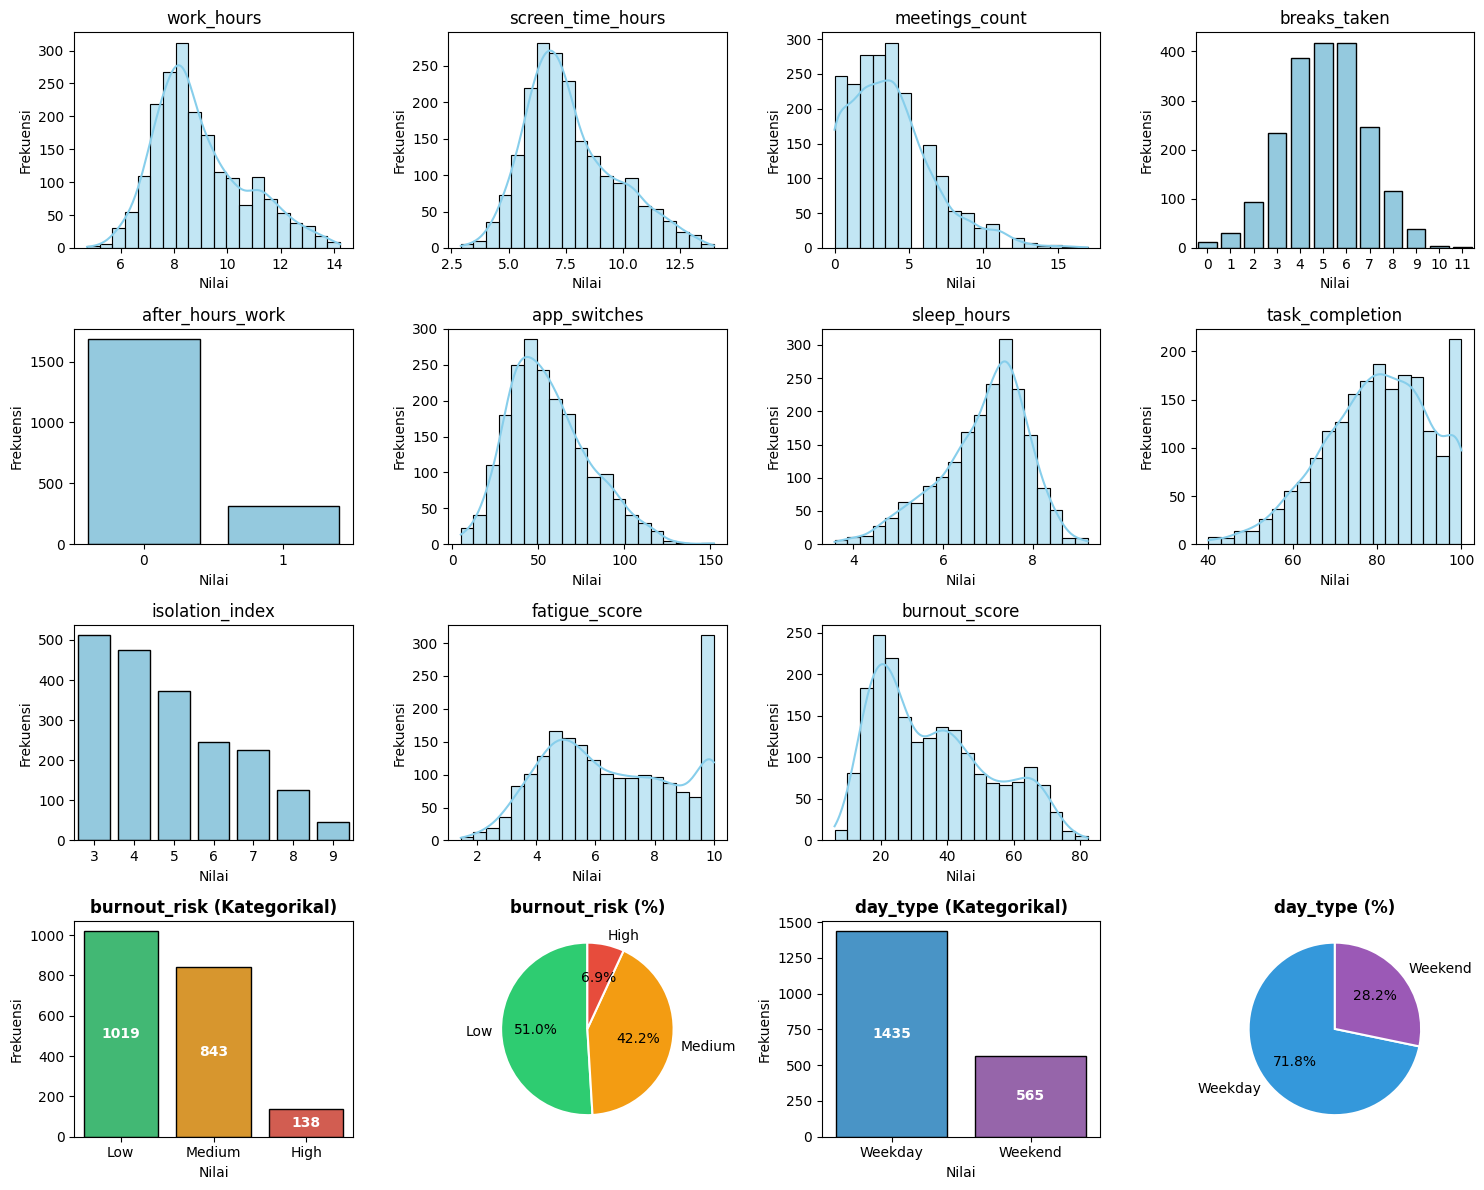

In [8]:
# ============================================================================
# CELL 4.2: Exploratory Data Analysis (EDA) - Histogram
# ============================================================================

# 2. Histogram (Distribusi Data) - Format Grid 3x3
print("\n--- HISTOGRAM FITUR NUMERIK & BURNOUT RISK ---")
# Menyiapkan kanvas 4x4
fig, axes = plt.subplots(4, 4, figsize=(15, 12)) 
axes = axes.flatten() # Meratakan array axes agar mudah di-loop

# A. Menggambar Fitur Numerik
for i, col in enumerate(num_cols):
    # Penyesuaian agar fitur dengan sedikit nilai unik (seperti rapat) tetap rapi
    if len(df[col].unique()) <= 15:
        sns.countplot(x=df[col], color='skyblue', edgecolor='black', ax=axes[i])
    else:
        sns.histplot(df[col], bins=20, color='skyblue', edgecolor='black', kde=True, ax=axes[i])
    
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')

# B. Menambahkan 'burnout_risk' di grid kosong pertama setelah numerik
index_selanjutnya = i + 1
fig.delaxes(axes[index_selanjutnya]) # Hapus grid kosong

# hist burnout_risk di grid berikutnya
index_selanjutnya = i + 2
warna_burnout_risk = ['#2ecc71', '#f39c12', '#e74c3c'] # Hijau (Low), Oranye (Medium), Merah (High)
sns.countplot(
    x=df['burnout_risk'], 
    order=['Low', 'Medium', 'High'], 
    palette=warna_burnout_risk,
    edgecolor='black', 
    ax=axes[index_selanjutnya]
)
for container in axes[index_selanjutnya].containers:
    axes[index_selanjutnya].bar_label(container, fontsize=10, fontweight='bold', label_type='center', color='white')

axes[index_selanjutnya].set_title('burnout_risk (Kategorikal)', fontsize=12, fontweight='bold')
axes[index_selanjutnya].set_xlabel('Nilai')
axes[index_selanjutnya].set_ylabel('Frekuensi')

# pie chart untuk burnout_risk di grid berikutnya
index_selanjutnya += 1
nilai_risk  = df['burnout_risk'].value_counts().reindex(['Low', 'Medium', 'High'])
axes[index_selanjutnya].pie(
    nilai_risk,
    labels=nilai_risk.index,
    colors=warna_burnout_risk,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[index_selanjutnya].set_title('burnout_risk (%)', fontsize=12, fontweight='bold')

# hist day_type di grid berikutnya
index_selanjutnya += 1
warna_day_type = ['#3498db', '#9b59b6']
sns.countplot(
    x=df['day_type'],
    order=['Weekday', 'Weekend'],
    palette=warna_day_type,  # Biru (Weekday), Ungu (Weekend)
    edgecolor='black',
    ax=axes[index_selanjutnya]
)
for container in axes[index_selanjutnya].containers:
    axes[index_selanjutnya].bar_label(container, fontsize=10, fontweight='bold', label_type='center', color='white')

axes[index_selanjutnya].set_title('day_type (Kategorikal)', fontsize=12, fontweight='bold')
axes[index_selanjutnya].set_xlabel('Nilai')
axes[index_selanjutnya].set_ylabel('Frekuensi')

# pie chart untuk day_type di grid berikutnya
index_selanjutnya += 1
nilai_day  = df['day_type'].value_counts().reindex(['Weekday', 'Weekend'])
axes[index_selanjutnya].pie(
    nilai_day,
    labels=nilai_day.index,
    colors= warna_day_type,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[index_selanjutnya].set_title('day_type (%)', fontsize=12, fontweight='bold')

# C. Menghapus kotak grid yang benar-benar kosong
for j in range(index_selanjutnya + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('../graphs_init/viz_init_02_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

### Analisis Histogram Distribusi Fitur (Explanatory Data Analysis)

**1. Distribusi Normal (Simetris)**<br>
Fitur `work_hours`, `screen_time_hours`, `app_switches`, dan `sleep_hours` 
menunjukkan distribusi yang mendekati kurva normal (bell-shaped), dengan data 
tersebar merata di sekitar nilai tengah. Pola ini ideal untuk fitur machine 
learning karena tidak memerlukan transformasi khusus.

**2. Miring Kanan (Right-Skewed)**<br>
`meetings_count` dan `burnout_score` menunjukkan mayoritas data menumpuk di 
nilai rendah dengan ekor panjang ke kanan, mengindikasikan sebagian besar 
karyawan memiliki sedikit rapat dan burnout score yang relatif rendah. 
`isolation_index` juga miring kanan dengan mayoritas karyawan berada di nilai 
3–4, artinya sebagian besar tidak merasa terisolasi secara signifikan.

**3. Miring Kiri (Left-Skewed)**<br>
`task_completion` menunjukkan mayoritas karyawan menyelesaikan 60–100% tugas 
mereka, dengan sangat sedikit yang memiliki tingkat penyelesaian rendah.

**4. Temuan yang Perlu Dicurigai**<br>
`fatigue_score` menunjukkan lonjakan ekstrem yang tidak natural pada nilai
maksimum (10), jauh lebih tinggi dibanding nilai-nilai lainnya. Pada data
self-reported, pola seperti ini mengindikasikan adanya bias responden yang
cenderung memilih nilai ekstrem. `breaks_taken` menunjukkan distribusi
multimodal dengan beberapa puncak, mengindikasikan adanya subkelompok
perilaku berbeda dalam dataset. `after_hours_work` menunjukkan ketimpangan
yang sangat signifikan dengan sekitar 1.600 karyawan tidak lembur dibanding
~300 yang lembur. Sebagai fitur binary, informasi yang dapat diberikan
terbatas, hanya mampu membedakan "lembur atau tidak" tanpa menangkap
durasi atau intensitas lembur yang sebenarnya. Hal ini turut berkontribusi
pada korelasi yang lemah terhadap `burnout_score` (+0.30).

**5. Distribusi Kategorikal**<br>
`burnout_risk` menunjukkan distribusi yang cukup seimbang (Low: 1.019, 
Medium: 843, High: 138), jauh lebih baik dibanding dataset serupa yang 
umumnya didominasi kelas Low. `day_type` menunjukkan proporsi Weekday (~72%) 
lebih dominan dibanding Weekend (~28%), yang wajar secara konteks work-from-home.


--- BOXPLOT FITUR NUMERIK ---


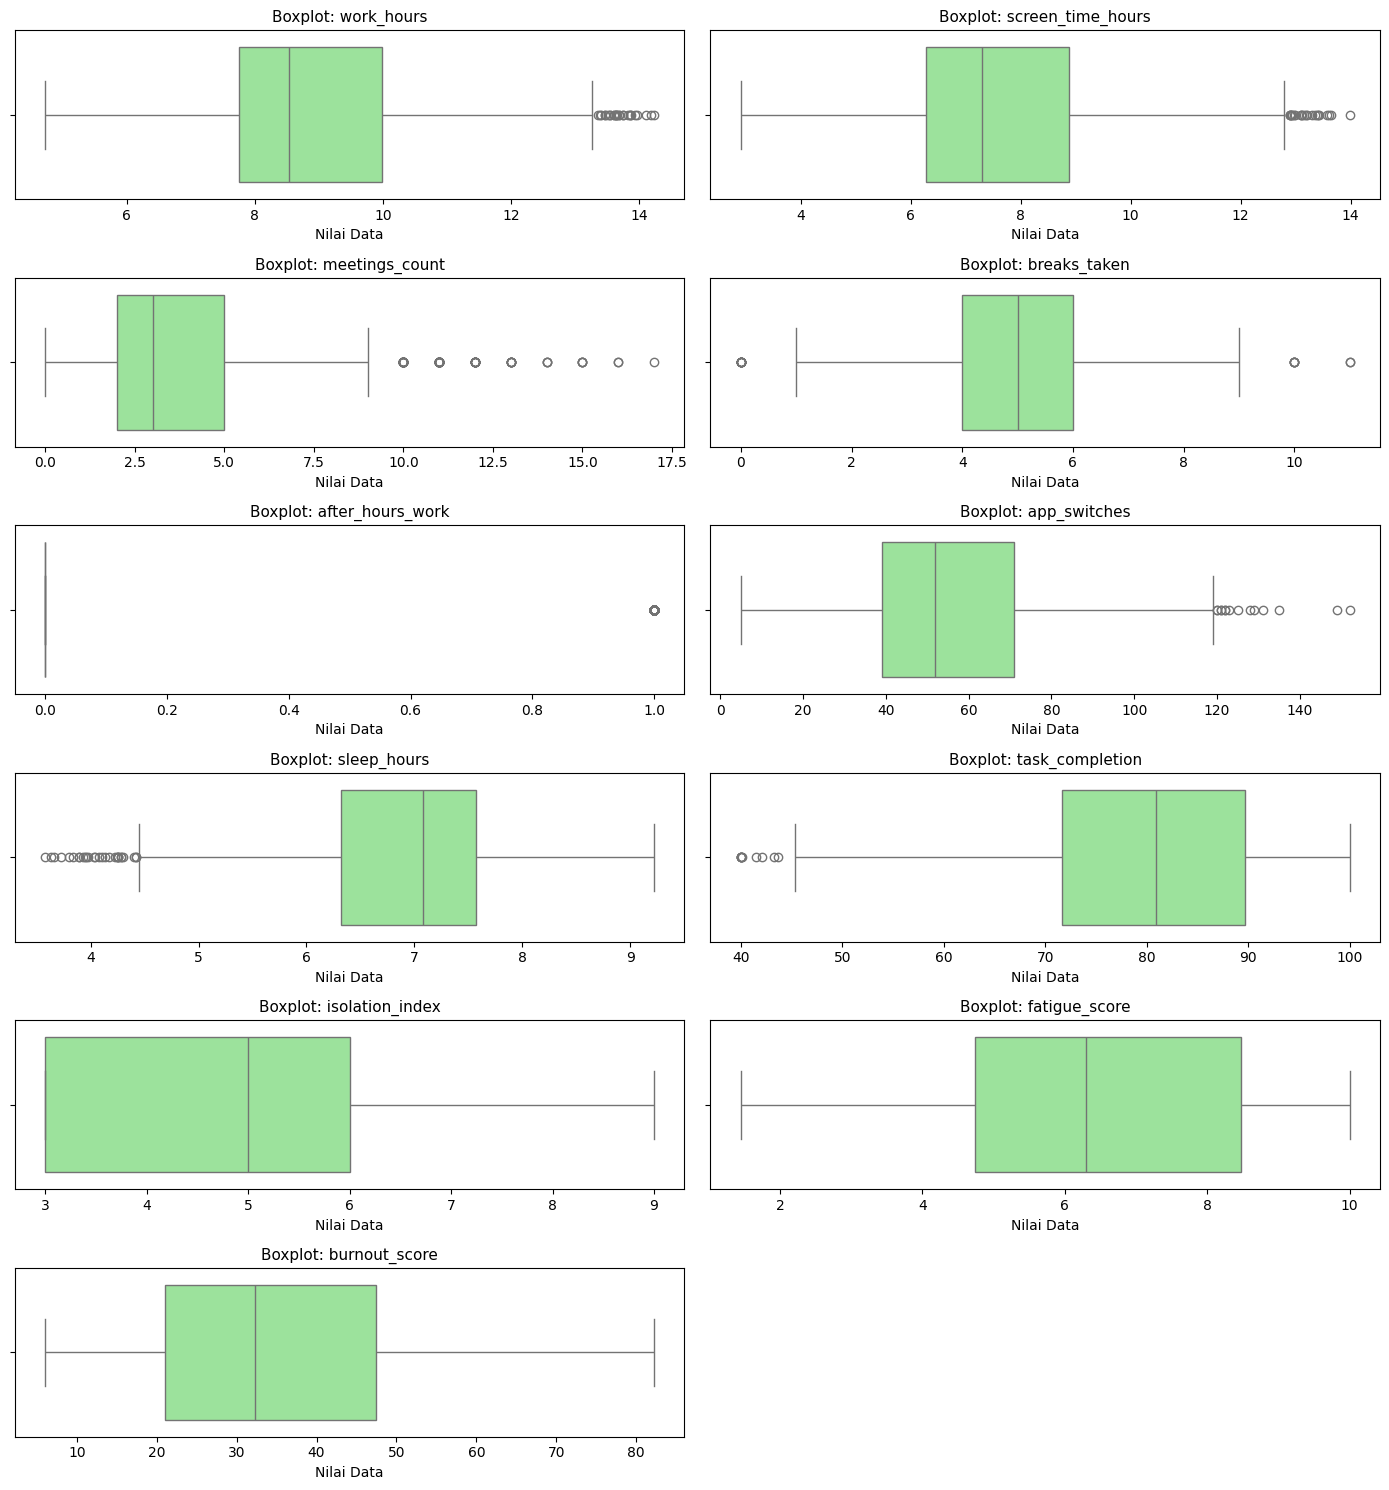

In [9]:
# ============================================================================
# CELL 4.3: Exploratory Data Analysis (EDA) - Boxplot
# ============================================================================

print("\n--- BOXPLOT FITUR NUMERIK ---")

n_cols = 2
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 2.5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], orient="h", color='lightgreen', ax=axes[i])
    axes[i].set_title(f"Boxplot: {col}", fontsize=11)
    axes[i].set_xlabel("Nilai Data", fontsize=10)

# Hapus axes kosong kalau num_cols ganjil
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('../graphs_init/viz_init_03_boxplots_all.png', dpi=150, bbox_inches='tight')
plt.show()

### Analisis Boxplot Deteksi Outlier (Explanatory Data Analysis)

**Kesimpulan Umum (TL:DR)**<br>
Fitur yang paling memerlukan penanganan outlier adalah `meetings_count` 
(banyak outlier kanan), `sleep_hours` (outlier kiri bermakna karena korelasi 
kuat dengan target), dan `work_hours` (outlier kanan). Fitur `after_hours_work` 
sebaiknya tidak dianalisis melalui boxplot karena sifatnya yang binary.

**1. work_hours**<br>
Nilai tengah (median) sekitar 9 jam dengan IQR antara 8–10 jam. Terdapat 
beberapa outlier di sisi kanan pada rentang 13–14 jam, mengindikasikan 
sekelompok kecil karyawan yang bekerja jauh melebihi rata-rata.

**2. screen_time_hours**<br>
Distribusi cukup simetris dengan median sekitar 7.5 jam dan IQR 6.5–9 jam. 
Terdapat beberapa outlier di kanan (13–14 jam), serupa dengan pola work_hours 
— konsisten dengan korelasi tinggi antar keduanya (0.98).

**3. meetings_count**<br>
Median rendah sekitar 3 rapat dengan IQR 2–5. Namun terdapat banyak outlier 
di sisi kanan (10–17.5 rapat), mengindikasikan sebagian kecil karyawan 
menghadiri jumlah rapat yang jauh di atas rata-rata. Fitur ini memiliki 
outlier terbanyak dibanding fitur lainnya.

**4. breaks_taken**<br>
Distribusi paling simetris — median sekitar 5, IQR 4–6, dengan hanya satu 
outlier di kiri (~0) dan dua di kanan (~10–11). Secara keseluruhan paling 
bersih dari outlier.

**5. after_hours_work**<br>
Boxplot kolaps mendekati 0 karena fitur ini bersifat binary (0/1). Nilai 1 
muncul sebagai outlier, mencerminkan ketimpangan distribusi yang sudah 
terlihat di histogram. Boxplot tidak ideal untuk fitur binary.

**6. app_switches**<br>
Median sekitar 60 dengan IQR 40–75. Terdapat beberapa outlier di kanan 
(125–150), mengindikasikan sekelompok karyawan dengan kebiasaan multitasking 
yang sangat intensif.

**7. sleep_hours**<br>
Median sekitar 7 jam dengan IQR 6.5–8 jam. Outlier berada di sisi kiri 
(3–4.5 jam), menunjukkan sekelompok karyawan yang tidur sangat kurang. 
Mengingat korelasinya yang kuat dengan burnout_score (-0.80), outlier ini 
perlu diperhatikan.

**8. task_completion**<br>
Median sekitar 80% dengan IQR 70–90%. Outlier berada di sisi kiri (40–50%), 
mencerminkan sekelompok kecil karyawan dengan tingkat penyelesaian tugas 
yang jauh di bawah rata-rata.

**9. isolation_index**<br>
Box berada di rentang 3–6 dengan median sekitar 4.5. Tidak ada outlier 
yang terdeteksi — distribusi miring kanan tanpa nilai ekstrem.

**10. fatigue_score**<br>
IQR yang lebar (5–8.5) mengindikasikan variabilitas tinggi dalam tingkat 
kelelahan antar karyawan. Tidak ada outlier formal, namun rentang yang 
mencapai nilai minimum 1 hingga maksimum 10 menunjukkan perbedaan kondisi 
yang sangat besar antar individu.

**11. burnout_score**<br>
Median sekitar 35 dengan IQR 22–47. Distribusi cukup lebar mencakup rentang 
8–80, tanpa outlier ekstrem yang mencolok. Ini menunjukkan variasi burnout 
yang cukup merata di seluruh dataset.

In [10]:
# ============================================================================
# CELL 5: Data Cleaning - Drop Dupes & Irrelevant Columns
# ============================================================================

# Catat baris sebelum dihapus
baris_sebelum_dupe = df.shape[0]

# Cek dan buang duplikat (kalau ada)
print(f"Jumlah duplikat: {df.duplicated().sum()}")
df = df.drop_duplicates(keep='first')

# Catat baris setelah dan tampilkan laporannya
baris_setelah_dupe = df.shape[0]
print(f"Total baris sebelum drop dupes: {baris_sebelum_dupe}\n")
print(f"Baris dihapus: {baris_sebelum_dupe - baris_setelah_dupe}")
print(f"Total baris setelah drop dupes: {baris_setelah_dupe}")

# Drop kolom yang tidak mencerminkan perilaku individu
# (Catatan: user_id sudah di-drop di CELL 1)
# yang dimaksud irrelevant di sini adalah kolom yang lebih mencerminkan performa perusahaan, bukan karakter individu

print("\n--- TAMPILAN 5 DATA PERTAMA ---")
display(df.head())

Jumlah duplikat: 0
Total baris sebelum drop dupes: 2000

Baris dihapus: 0
Total baris setelah drop dupes: 2000

--- TAMPILAN 5 DATA PERTAMA ---


,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,app_switches,sleep_hours,task_completion,isolation_index,fatigue_score,burnout_score,burnout_risk
0,Weekday,7.74,5.99,3,7,0,50,7.50,74.80,4,3.51,17.23,Low
1,Weekday,8.48,7.23,3,5,0,63,7.31,86.36,4,5.15,24.01,Low
2,Weekend,8.39,7.14,1,5,0,27,6.73,89.23,8,7.85,51.46,Medium
3,Weekday,12.48,12.23,4,1,1,89,6.55,64.47,5,10.00,55.50,Medium
4,Weekend,8.85,7.35,4,6,0,40,8.03,98.62,3,3.45,11.95,Low


In [11]:
# ============================================================================
# CELL 6.1: Feature Engineering & Label Encoding
# ============================================================================

# Simpan sebelum diubah
df_original = df.copy()

# # 1. Feature Engineering: Membuat 'stress_score' (Indeks beban kognitif ekstra, dihitung berdasarkan logika heuristik, TIDAK DIPERLUKAN UNTUK DATASET INI)
# df['stress_score'] = np.maximum(0, df['work_hours'] - 8) + df['after_hours_work'] + (df['meetings_count'] * 0.5)
# print("="*70)
# print(" FITUR 'stress_score' BERHASIL DIBUAT.")
# print("="*70)

# 2. Label Encoding (Binary & Ordinal)
df['day_type'] = df['day_type'].map({'Weekday': 0, 'Weekend': 1})
df['burnout_risk'] = df['burnout_risk'].map({'Low': 0, 'Medium': 1, 'High': 2})
print("\n" + "="*70)
print(" LABEL ENCODING PADA 'day_type' DAN 'burnout_risk' SELESAI.")
print("="*70)

# Cek hasil akhir sebelum data dipecah
df.head()


 LABEL ENCODING PADA 'day_type' DAN 'burnout_risk' SELESAI.


,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,app_switches,sleep_hours,task_completion,isolation_index,fatigue_score,burnout_score,burnout_risk
0,0,7.74,5.99,3,7,0,50,7.50,74.80,4,3.51,17.23,0
1,0,8.48,7.23,3,5,0,63,7.31,86.36,4,5.15,24.01,0
2,1,8.39,7.14,1,5,0,27,6.73,89.23,8,7.85,51.46,1
3,0,12.48,12.23,4,1,1,89,6.55,64.47,5,10.00,55.50,1
4,1,8.85,7.35,4,6,0,40,8.03,98.62,3,3.45,11.95,0


In [12]:
# # ============================================================================
# # CELL 6.1 (continued): Visualize New Feature (stress_score) Distribution & Outlier
# # ============================================================================

# # Menyiapkan kanvas dengan 1 baris dan 2 kolom (Kiri-Kanan)
# plt.figure(figsize=(12, 4))

# # 1. HISTOGRAM
# plt.subplot(1, 2, 1)
# sns.histplot(df['stress_score'], kde=True, color='mediumorchid', edgecolor='black', bins=20)
# plt.title('Distribusi stress_score', fontsize=12, fontweight='bold')
# plt.xlabel('Nilai Skor')
# plt.ylabel('Jumlah Responden')

# # 2. BOXPLOT
# plt.subplot(1, 2, 2)
# sns.boxplot(x=df['stress_score'], color='mediumorchid')
# plt.title('Boxplot stress_score (Deteksi Outlier)', fontsize=12, fontweight='bold')
# plt.xlabel('Nilai Skor')

# # Menampilkan grafik dengan rapi
# plt.tight_layout()
# plt.show()

# # Cek persisnya seberapa jauh batas wajarnya
# Q1 = df['stress_score'].quantile(0.25)
# Q3 = df['stress_score'].quantile(0.75)
# IQR = Q3 - Q1
# batas_atas = Q3 + 1.5 * IQR
# batas_bawah = Q1 - 1.5 * IQR

# print(f"INFO: Berdasarkan hitungan IQR, nilai stress_score di atas {batas_atas:.2f} dan di bawah {batas_bawah:.2f} dianggap sebagai OUTLIER.")

In [13]:
# ============================================================================
# CELL 7: Train/Test Split (Preventing Data Leakage Before Norm/Standard/Transform)
# ============================================================================
from sklearn.model_selection import train_test_split

# Fitur X yang disepakati untuk Regresi
fitur_x = [
    'work_hours',
    # 'screen_time_hours' <- drop karena multikolinearitas 0.98 dengan work_hours',
    'sleep_hours',
    'isolation_index',
    'fatigue_score',
]

X = df[fitur_x]
# Target Y adalah burnout_score (Angka asli)
y = df['burnout_score'] 

# Pemisahan 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah Data Training: {X_train.shape[0]} baris")
print(f"Jumlah Data Testing: {X_test.shape[0]} baris")

Jumlah Data Training: 1600 baris
Jumlah Data Testing: 400 baris


In [14]:
# ============================================================================
# CELL 8.1: Handle Missing Values (Median Imputation)
# ============================================================================
from sklearn.impute import SimpleImputer

# --- CEK MISSING VALUES SEBELUM HANDLING ---
print("--- CEK MISSING VALUES SEBELUM HANDLING ---")
print(f"Total X_train : {X_train.isnull().values.sum()}")
print(f"Total X_test  : {X_test.isnull().values.sum()}")

# Inisialisasi pengisi nilai kosong menggunakan Median
handling_missing = 'median'
imputer = SimpleImputer(strategy=handling_missing)
print("\n" + "="*70)
print(f" HANDLE MISSING VALUE MENGGUNAKAN {handling_missing} SELESAI.")
print("="*70)

# PENTING: Fit (belajar median) HANYA dari X_train, lalu isi ke X_train dan X_test
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

# Cek Missing Value Kembali
print("\n--- CEK MISSING VALUES SETELAH HANDLING ---")
print(f"Total X_train_imputed : {X_train_imputed.isnull().values.sum()}")
print(f"Total X_test_imputed  : {X_test_imputed.isnull().values.sum()}")

# --- Menampilkan Dataframe SEBELUM Normalisasi ---
print("\n--- TAMPILAN 5 DATA TRAIN PERTAMA (SEBELUM NORMALISASI) ---")
display(X_train_imputed.head())

print("\n--- TAMPILAN 5 DATA TEST PERTAMA (SEBELUM NORMALISASI) ---")
display(X_test_imputed.head())

--- CEK MISSING VALUES SEBELUM HANDLING ---
Total X_train : 0
Total X_test  : 0

 HANDLE MISSING VALUE MENGGUNAKAN median SELESAI.

--- CEK MISSING VALUES SETELAH HANDLING ---
Total X_train_imputed : 0
Total X_test_imputed  : 0

--- TAMPILAN 5 DATA TRAIN PERTAMA (SEBELUM NORMALISASI) ---


,work_hours,sleep_hours,isolation_index,fatigue_score
968,8.53,5.67,5.0,7.66
240,7.12,7.29,4.0,4.18
819,8.53,7.42,3.0,4.68
692,7.30,7.01,4.0,5.40
420,7.26,7.32,5.0,4.13



--- TAMPILAN 5 DATA TEST PERTAMA (SEBELUM NORMALISASI) ---


,work_hours,sleep_hours,isolation_index,fatigue_score
1860,8.96,5.97,8.0,7.71
353,12.45,6.09,5.0,10.00
1333,7.31,6.23,5.0,7.72
905,8.36,7.28,5.0,6.57
1289,9.69,6.48,4.0,10.00


In [15]:
# ============================================================================
# CELL 8.2: Extract range Automatically Using Rule-Based (Min-Max) from Dataset
# ============================================================================

# 1. Cari nilai paling minimum dari kategori Medium (1) dan High (2) di dataset asli (df)
# Karena di CELL 6 kita sudah melakukan: Low = 0, Medium = 1, High = 2
batas_min_medium = df[df['burnout_risk'] == 1]['burnout_score'].min()
batas_min_high = df[df['burnout_risk'] == 2]['burnout_score'].min()

print("="*70)
print(" BATAS RULE-BASED OTOMATIS BERHASIL DITEMUKAN")
print("="*70)
print(f"Batas masuk Medium : {batas_min_medium}")
print(f"Batas masuk High   : {batas_min_high}")

# 2. Fungsi dinamis menggunakan variabel di atas (Disimpan untuk Cell 13 & 14 nanti)
def klasifikasi_burnout_dinamis(skor):
    if skor < batas_min_medium: 
        return 'Low'
    elif skor < batas_min_high:
        return 'Medium'
    else:
        return 'High'

 BATAS RULE-BASED OTOMATIS BERHASIL DITEMUKAN
Batas masuk Medium : 33.04
Batas masuk High   : 66.0


In [16]:
# ============================================================================
# CELL 9: Stitching Dataset to Export the Cleaned Dataset
# ============================================================================

# 1. Gabungkan X_train dan X_test yang sudah bersih dari missing value
df_full_features = pd.concat([X_train_imputed, X_test_imputed])

# 2. Gabungkan juga y_train dan y_test (Target) agar tabelnya lengkap
df_full_target = pd.concat([y_train, y_test])

# 3. Satukan fitur dan target ke dalam satu variabel baru yang utuh
df_clean = df_full_features.copy()
df_clean['burnout_score'] = df_full_target

# 4. KUNCI UTAMA: Urutkan berdasarkan Index agar posisinya kembali ke urutan Excel asli!
df_clean = df_clean.sort_index()

# 5. CANGKOK KOLOM ASLI: Copy langsung kategori risiko dari dataset df mentah
# Menggunakan .loc untuk memastikan nomor barisnya benar-benar cocok dan tidak tertukar
df_clean['burnout_risk'] = df_original.loc[df_clean.index, 'burnout_risk']

print("="*70)
print(" BERHASIL MEMBUAT CLEAN DATASET")
print("="*70)
print(f"\nTotal baris sekarang: {df_clean.shape[0]}")
print("\n--- TAMPILAN 5 DATA PERTAMA ---")
display(df_clean.head())

# (Opsional) Jika ingin mengekspornya langsung ke CSV:
nama_file_ekspor_df_clean = '..\dataset_wfh2_reduced_clean.csv'
df_clean.to_csv(nama_file_ekspor_df_clean, index=True, index_label='index')
print("\n" + "#"*70)
print(f" CLEAN DATASET DIEKSPOR DENGAN NAMA: {nama_file_ekspor_df_clean}")
print("#"*70)

 BERHASIL MEMBUAT CLEAN DATASET

Total baris sekarang: 2000

--- TAMPILAN 5 DATA PERTAMA ---


,work_hours,sleep_hours,isolation_index,fatigue_score,burnout_score,burnout_risk
0,7.74,7.50,4.0,3.51,17.23,Low
1,8.48,7.31,4.0,5.15,24.01,Low
2,8.39,6.73,8.0,7.85,51.46,Medium
3,12.48,6.55,5.0,10.00,55.50,Medium
4,8.85,8.03,3.0,3.45,11.95,Low



######################################################################
 CLEAN DATASET DIEKSPOR DENGAN NAMA: ..\dataset_wfh2_reduced_clean.csv
######################################################################


In [17]:
# ============================================================================
# CELL 10.1: Check Outliers (Transform & Normalization)
# ============================================================================

# Kolom numerik yang akan kita cek outliernya
kolom_numerik = [
    'work_hours',
    # 'screen_time_hours' <- drop karena multikolinearitas 0.98 dengan work_hours
    'sleep_hours',
    'isolation_index',
    'fatigue_score',
    # 'day_type' <- drop karena data kategorikal
]

# --- Menghitung Outlier dengan Metode IQR ---
def hitung_total_outlier(df, kolom_list):
    total_outlier = 0
    for col in kolom_list:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        batas_bawah = Q1 - 1.5 * IQR
        batas_atas = Q3 + 1.5 * IQR
        # Hitung baris yang nilainya di luar batas kewajaran
        outlier_col = ((df[col] < batas_bawah) | (df[col] > batas_atas)).sum()
        total_outlier += outlier_col
    return total_outlier

# Hitung dan tampilkan outlier SEBELUM normalisasi
outlier_sebelum = hitung_total_outlier(X_train_imputed, kolom_numerik)

print("="*70)
print(f" JUMLAH OUTLIER SEBELUM LOG & Z-SCORE : {outlier_sebelum}")
print("="*70)
print("*Catatan: Angka ini didapat dari perhitungan batas IQR (Q1 dan Q3).")

 JUMLAH OUTLIER SEBELUM LOG & Z-SCORE : 46
*Catatan: Angka ini didapat dari perhitungan batas IQR (Q1 dan Q3).


In [18]:
# ============================================================================
# CELL 10.2: WINSORIZATION (Optional, ubah WINSOR_AKTIF = False untuk menonaktifkan)
# ============================================================================

WINSOR_AKTIF = False

# Kolom yang di-winsorisasi: semua numerik KECUALI yang akan di-log
# (meetings_count, isolation_index, fatigue_score ditangani log transform)
kolom_winsor = [
    'work_hours',
    'sleep_hours',
]

if WINSOR_AKTIF:
    print("--- PROSES WINSORIZATION DIMULAI ---")
    for col in kolom_winsor:
        # Batas IQR dihitung HANYA dari X_train untuk mencegah data leakage
        Q1 = X_train_imputed[col].quantile(0.25)
        Q3 = X_train_imputed[col].quantile(0.75)
        IQR = Q3 - Q1
        batas_bawah = Q1 - 1.5 * IQR
        batas_atas  = Q3 + 1.5 * IQR

        X_train_imputed[col] = X_train_imputed[col].clip(lower=batas_bawah, upper=batas_atas)
        X_test_imputed[col]  = X_test_imputed[col].clip(lower=batas_bawah, upper=batas_atas)

        print(f"[{col}] Rentang diubah: {batas_bawah:.2f} s/d {batas_atas:.2f}")

    outlier_setelah_winsor = hitung_total_outlier(X_train_imputed, kolom_winsor)
    print("\n" + "="*70)
    print(" WINSORIZATION SELESAI")
    print("="*70)
    print(f" JUMLAH OUTLIER SETELAH WINSORIZATION: {outlier_setelah_winsor} (seharusnya 0)")
else:
    print("="*70)
    print(" WINSORIZATION DINONAKTIFKAN")
    print("="*70)

 WINSORIZATION DINONAKTIFKAN


In [19]:
# ============================================================================
# CELL 10.3: Logarithm Transform (Log1p) — ubah LOG_TRANSFORM_AKTIF = False untuk menonaktifkan
# ============================================================================

# VARIABEL KONDISI — ini yang dikontrol
LOG_TRANSFORM_AKTIF = False

# Kolom X yang akan di-log (right-skewed)
kolom_log = [
    'isolation_index',
    'fatigue_score'
]

if LOG_TRANSFORM_AKTIF:
    X_train_imputed[kolom_log] = np.log1p(X_train_imputed[kolom_log])
    X_test_imputed[kolom_log]  = np.log1p(X_test_imputed[kolom_log])

    print("="*70)
    print(" TRANSFORMASI LOG1P PADA FITUR X SELESAI")
    print("="*70)
    print(f"Kolom yang di-transform: {kolom_log}")

    outlier_setelah = hitung_total_outlier(X_train_imputed, kolom_numerik)
    print(f"\n JUMLAH OUTLIER SETELAH LOG & SEBELUM Z-SCORE : {outlier_setelah}")
else:
    print("\n" + "="*70)
    print(" LOG TRANSFORM DINONAKTIFKAN — FITUR X TIDAK DIUBAH")
    print("="*70)


 LOG TRANSFORM DINONAKTIFKAN — FITUR X TIDAK DIUBAH


In [20]:
# ============================================================================
# CELL 11: Normalization (Z-Score)
# ============================================================================
from sklearn.preprocessing import StandardScaler

# VARIABEL KONDISI
ZSCORE_AKTIF = False

if ZSCORE_AKTIF:
    scaler = StandardScaler()

    # Fit scaler HANYA pada X_train
    X_train_imputed[kolom_numerik] = scaler.fit_transform(X_train_imputed[kolom_numerik])
    X_test_imputed[kolom_numerik] = scaler.transform(X_test_imputed[kolom_numerik])

    print("="*70)
    print(" NORMALISASI Z-SCORE BERHASIL DITERAPKAN.")
    print("="*70)

    # --- Menampilkan Dataframe yang Sudah Dinormalisasi ---
    print("\n--- TAMPILAN 5 DATA PERTAMA SETELAH NORMALISASI (Z-Score) ---")
    display(X_train_imputed.head())

    # Hitung dan tampilkan outlier SETELAH normalisasi
    # (Fungsi hitung_total_outlier akan otomatis terbaca dari CELL 8)
    outlier_setelah = hitung_total_outlier(X_train_imputed, kolom_numerik)

    print("\n" + "="*70)
    print(f" JUMLAH TITIK OUTLIER SETELAH LOG & SETELAH Z-SCORE: {outlier_setelah}")
    print("="*70)
else:
    scaler = None
    print("="*70)
    print(" Z-SCORE DINONAKTIFKAN — DATA TIDAK DINORMALISASI")
    print("="*70)

 Z-SCORE DINONAKTIFKAN — DATA TIDAK DINORMALISASI


In [21]:
# ============================================================================
# CELL 12.1: Training & Hyperparameter & Evaluation (Random Forest + GridSearchCV)
# ============================================================================
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score

# 1. TRANSFORMASI TARGET Y
if LOG_TRANSFORM_AKTIF:
    y_train_fit = np.log1p(y_train)
    print(" Target Y di-log sebelum training.")
else:
    y_train_fit = y_train
    print(" Target Y TIDAK di-log.")

# 2. GRID SEARCH
print("\n--- MEMULAI GRID SEARCH RANDOM FOREST (Mohon tunggu...) ---")

param_grid = {
    'n_estimators' : [100, 200, 300],
    'max_depth'    : [None, 5, 10, 15],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf'  : [1, 2, 4]
}

rf_dasar = RandomForestRegressor(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf_dasar,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_imputed, y_train_fit)
model_rf = grid_search.best_estimator_

print("\n" + "="*70)
print(" MODEL RANDOM FOREST TERBAIK DITEMUKAN")
print("="*70)
print(f" Best Params   : {grid_search.best_params_}")
print("="*70)

# 3. PREDIKSI
y_pred_raw = model_rf.predict(X_test_imputed)

# 4. INVERSE LOG TARGET Y
if LOG_TRANSFORM_AKTIF:
    y_pred = np.expm1(y_pred_raw)
else:
    y_pred = y_pred_raw

# 5. EVALUASI
mae  = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

label_winsor = "+ WINSOR" if WINSOR_AKTIF        else ""
label_log    = "+ LOG"    if LOG_TRANSFORM_AKTIF else ""
label_zscore = "+ Z-SCORE" if ZSCORE_AKTIF       else ""
label_config = f"RF {label_winsor} {label_log} {label_zscore}".replace("  ", " ").strip()

print("\n" + "="*70)
print(f" HASIL EVALUASI MODEL ({label_config})")
print("="*70)
print(f"R²   (Akurasi Varians)         : {r2:.4f} (Mendekati 1.0 semakin baik)")
print(f"MAE  (Rata-rata Error Absolut) : {mae:.2f} poin")
print(f"MAPE (Persentase Meleset)      : {mape:.2%} (Mendekati 0% semakin baik)")
print(f"RMSE (Rata-rata Error Poin)    : {rmse:.2f} poin")
print("="*70)

# 6. CEK SELISIH R² TRAINING VS TESTING
y_train_pred_raw = model_rf.predict(X_train_imputed)
y_train_pred     = np.expm1(y_train_pred_raw) if LOG_TRANSFORM_AKTIF else y_train_pred_raw

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_pred)
selisih  = abs(r2_train - r2_test)

print("\n" + "="*70)
print(" CEK SELISIH R² TRAINING VS TESTING")
print("="*70)
print(f"R² Train : {r2_train:.4f}")
print(f"R² Test  : {r2_test:.4f}")
print(f"Selisih  : {selisih:.4f}")
print(f"MAPE     : {mape:.2%}")
print("\n Interpretasi:")
print("  MAPE besar + Selisih kecil = Underfitting")
print("  MAPE kecil + Selisih besar = Overfitting")
print("  MAPE kecil + Selisih kecil = Ideal")
print("="*70)

 Target Y TIDAK di-log.

--- MEMULAI GRID SEARCH RANDOM FOREST (Mohon tunggu...) ---
Fitting 3 folds for each of 108 candidates, totalling 324 fits

 MODEL RANDOM FOREST TERBAIK DITEMUKAN
 Best Params   : {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

 HASIL EVALUASI MODEL (RF)
R²   (Akurasi Varians)         : 0.9927 (Mendekati 1.0 semakin baik)
MAE  (Rata-rata Error Absolut) : 1.01 poin
MAPE (Persentase Meleset)      : 2.94% (Mendekati 0% semakin baik)
RMSE (Rata-rata Error Poin)    : 1.48 poin

 CEK SELISIH R² TRAINING VS TESTING
R² Train : 0.9991
R² Test  : 0.9927
Selisih  : 0.0064
MAPE     : 2.94%

 Interpretasi:
  MAPE besar + Selisih kecil = Underfitting
  MAPE kecil + Selisih besar = Overfitting
  MAPE kecil + Selisih kecil = Ideal



--- TINGKAT KEPENTINGAN FITUR (FEATURE IMPORTANCES) ---
fatigue_score        : 78.63%
isolation_index      : 15.69%
sleep_hours          : 4.19%
work_hours           : 1.49%


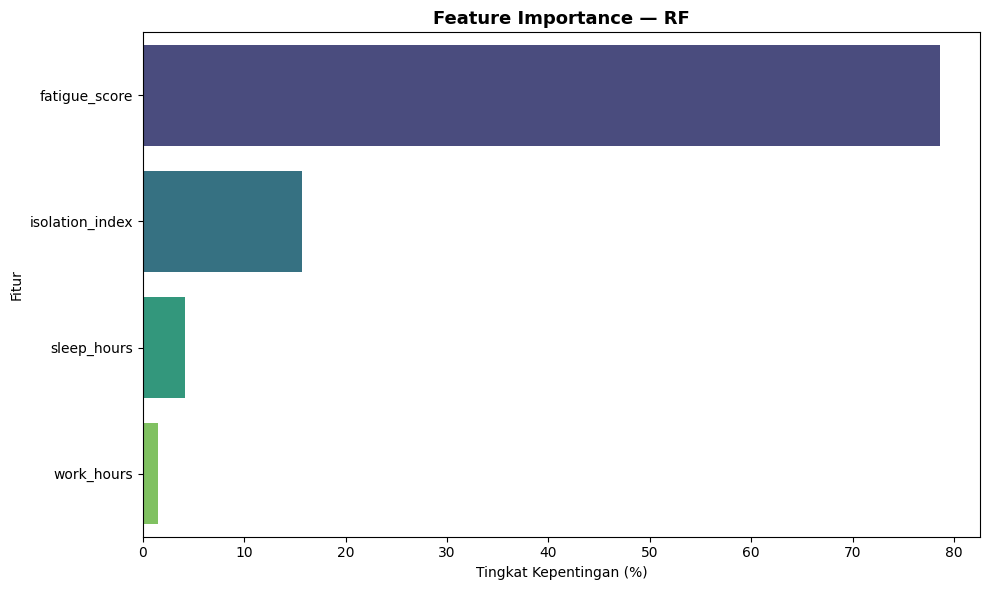

In [22]:
# ============================================================================
# CELL 12.2: FEATURE IMPORTANCE & VISUALIZATION
# ============================================================================

# FEATURE IMPORTANCE
print("\n--- TINGKAT KEPENTINGAN FITUR (FEATURE IMPORTANCES) ---")
importances   = model_rf.feature_importances_
fitur_penting = pd.DataFrame({
    'Fitur'       : X_train_imputed.columns,
    'Pentingnya (%)' : importances * 100
}).sort_values(by='Pentingnya (%)', ascending=False)

for _, row in fitur_penting.iterrows():
    print(f"{row['Fitur']:<20} : {row['Pentingnya (%)']:.2f}%")

# 8. GRAFIK FEATURE IMPORTANCE
plt.figure(figsize=(10, 6))
sns.barplot(
    data=fitur_penting,
    x='Pentingnya (%)',
    y='Fitur',
    palette='viridis'
)
plt.title(f'Feature Importance — {label_config}', fontsize=13, fontweight='bold')
plt.xlabel('Tingkat Kepentingan (%)')
plt.ylabel('Fitur')
plt.tight_layout()

nama_grafik_fi = f'./viz_feature_importance_rf6.png'
if not os.path.exists(nama_grafik_fi):
    plt.savefig(nama_grafik_fi, dpi=150, bbox_inches='tight')
plt.show()

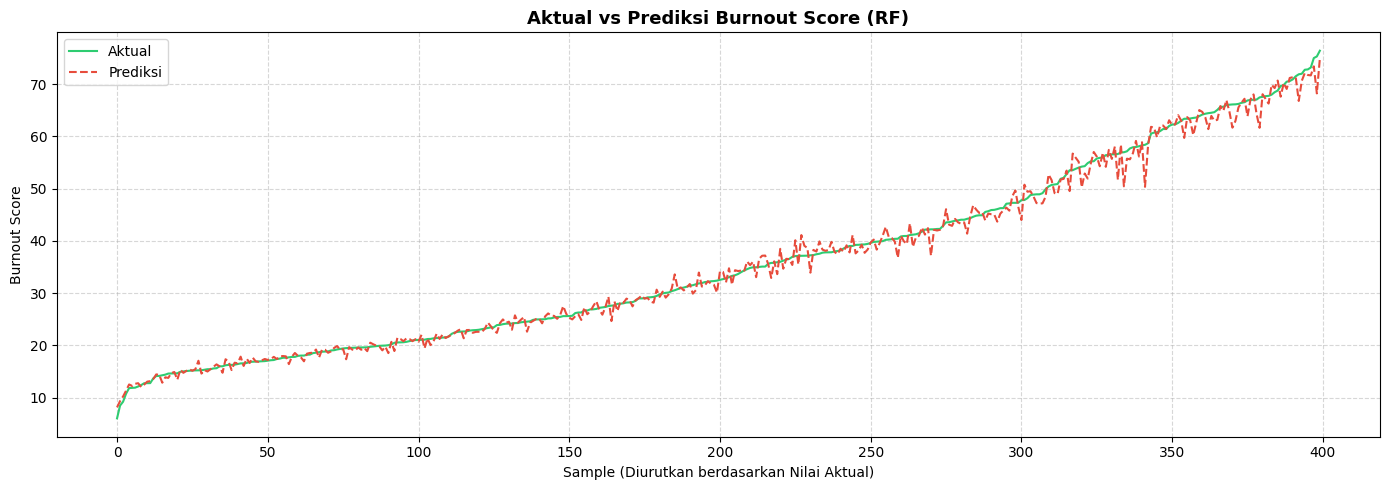

In [23]:
# ============================================================================
# CELL 12.3: Actual vs Predicted Plot (Inversed, so it's easier to interpret the error visually)
# ============================================================================

# GRAFIK AKTUAL VS PREDIKSI
plt.figure(figsize=(14, 5))

urutan           = np.argsort(y_test.values)
y_actual_sorted  = y_test.values[urutan]
y_predict_sorted = y_pred[urutan]

plt.plot(y_actual_sorted,  label='Aktual',   color='#2ecc71', linewidth=1.5)
plt.plot(y_predict_sorted, label='Prediksi', color='#e74c3c', linewidth=1.5, linestyle='--')

plt.title(f'Aktual vs Prediksi Burnout Score ({label_config})', fontsize=13, fontweight='bold')
plt.xlabel('Sample (Diurutkan berdasarkan Nilai Aktual)')
plt.ylabel('Burnout Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

nama_grafik_pred = f'./viz_aktual_vs_prediksi_rf6.png'
if not os.path.exists(nama_grafik_pred):
    plt.savefig(nama_grafik_pred, dpi=150, bbox_inches='tight')
plt.savefig(f'viz_rf6_01_actual_vs_predicted_({label_config}).png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# ============================================================================
# CELL 13: Save the Best Model & Scaler (Joblib)
# ============================================================================
# LSTM disimpan dengan format .keras, bukan .pkl seperti MLR
# Scaler tetap disimpan dengan joblib karena sklearn object
import joblib

# 1. Tentukan nama file dalam variabel agar fleksibel
nama_file_model  = 'model_burnout_rf6.pkl'
nama_file_scaler = 'scaler_burnout_rf6.pkl'

# 2. Simpan Model
joblib.dump(model_rf, nama_file_model)
print("#"*70)
print(f" MODEL BERHASIL DISIMPAN DENGAN NAMA : {nama_file_model}")

# Simpan scaler hanya kalau Z-Score aktif
if ZSCORE_AKTIF:
    joblib.dump(scaler, nama_file_scaler)
    print(f" SCALER BERHASIL DISIMPAN DENGAN NAMA : {nama_file_scaler}")
else:
    print(" SCALER TIDAK DISIMPAN (Z-Score dinonaktifkan)")
print("#"*70)

# --- Cara memanggilnya nanti ---
# model_loaded  = load_model(nama_file_model)
# scaler_loaded = joblib.load(nama_file_scaler)

######################################################################
 MODEL BERHASIL DISIMPAN DENGAN NAMA : model_burnout_rf6.pkl
 SCALER TIDAK DISIMPAN (Z-Score dinonaktifkan)
######################################################################


In [25]:
# ============================================================================
# CELL 14: Export Result Predict vs Actual to CSV (Scaled)
# ============================================================================

# 1. Gunakan X_test_imputed (berisi angka yang SUDAH di-Z-Score)
df_scaled = X_test_imputed.copy()

# 2. Tambahkan kolom Skor Aktual
df_scaled['burnout_score_actual'] = y_test.values

# 3. Tambahkan kolom Skor Prediksi (y_pred berasal dari CELL 12)
df_scaled['burnout_score_predict'] = np.round(y_pred, 2)

# 4. Tambahkan kolom Error (Seberapa jauh melesetnya, error_diff)
df_scaled['error_diff'] = np.round(np.abs(df_scaled['burnout_score_actual'] - df_scaled['burnout_score_predict']), 2)

# --- TAMBAHAN: KLASIFIKASI BURNOUT AKTUAL VS PREDIKSI ---
# Menggunakan fungsi dinamis dari CELL 8.2 (Min_max Rule-Based)
# Karena ini file SCALED, setelah diklasifikasi langsung kita map kembali ke angka kesepakatan CELL 6
df_scaled['burnout_risk_actual']  = df_scaled['burnout_score_actual'].apply(klasifikasi_burnout_dinamis).map({'Low': 0, 'Medium': 1, 'High': 2})
df_scaled['burnout_risk_predict'] = df_scaled['burnout_score_predict'].apply(klasifikasi_burnout_dinamis).map({'Low': 0, 'Medium': 1, 'High': 2})

# 5. Urutkan berdasarkan INDEX agar posisinya sama persis dengan Excel asli dan dataset Inverse
df_scaled_sorted = df_scaled.sort_index()

# 6. Ekspor ke file CSV dengan menyertakan Index
nama_file_ekspor_scaled = 'dataset_scaled_predict_rf6.csv'
df_scaled_sorted.to_csv(nama_file_ekspor_scaled, index=True, index_label='index')

print("#"*70)
print(f" PREDICT SCALED DIEKSPOR DENGAN NAMA: '{nama_file_ekspor_scaled}'")
print("#"*70)
print("\n--- 5 DATA PERTAMA HASIL SCALED ---")
display(df_scaled_sorted.head())

######################################################################
 PREDICT SCALED DIEKSPOR DENGAN NAMA: 'dataset_scaled_predict_rf6.csv'
######################################################################

--- 5 DATA PERTAMA HASIL SCALED ---


,work_hours,sleep_hours,isolation_index,fatigue_score,burnout_score_actual,burnout_score_predict,error_diff,burnout_risk_actual,burnout_risk_predict
23,8.27,8.09,4.0,3.17,14.18,14.39,0.21,0,0
29,9.03,7.68,3.0,6.57,23.22,23.19,0.03,0,0
30,9.41,5.98,6.0,7.35,47.30,48.59,1.29,1,1
32,7.95,7.77,4.0,3.63,16.22,17.37,1.15,0,0
44,9.46,7.12,3.0,10.00,37.16,41.13,3.97,1,1


In [26]:
# ============================================================================
# CELL 15: Export Result Predict vs Actual to CSV (Inverse)
# ============================================================================

# Nama file ekspor dibungkus dalam variabel agar fleksibel
nama_file_ekspor_inverse = 'dataset_inverse_predict_rf6.csv'

# 1. DUPLIKASI DATA UJIAN (X_test_imputed)
df_inverse = X_test_imputed.copy()

# 2. PROSES INVERSE TRANSFORM
# A. Kembalikan dari Z-Score (hanya kalau Z-Score aktif)
if ZSCORE_AKTIF:
    df_inverse[kolom_numerik] = scaler.inverse_transform(df_inverse[kolom_numerik])

# B. Kembalikan dari Log (hanya kalau Log aktif)
if LOG_TRANSFORM_AKTIF:
    df_inverse[kolom_log] = np.expm1(df_inverse[kolom_log])

# Kalau keduanya nonaktif, df_inverse sudah dalam skala asli
if not ZSCORE_AKTIF and not LOG_TRANSFORM_AKTIF:
    print(" INFO: Tidak ada inverse transform — data sudah dalam skala asli.")

# 3. GABUNGKAN DENGAN TARGET & PREDIKSI
df_inverse['burnout_score_actual']  = y_test.values
df_inverse['burnout_score_predict'] = np.round(y_pred, 2)

# 4. HITUNG SELISIH ERROR (error_diff) MUTLAK
df_inverse['error_diff'] = np.round(np.abs(df_inverse['burnout_score_actual'] - df_inverse['burnout_score_predict']), 2)

# --- TAMBAHAN: KLASIFIKASI RISIKO AKTUAL VS PREDIKSI ---
# Menggunakan fungsi dinamis dari CELL 8.2
df_inverse['burnout_risk_actual']  = df_inverse['burnout_score_actual'].apply(klasifikasi_burnout_dinamis)
df_inverse['burnout_risk_predict'] = df_inverse['burnout_score_predict'].apply(klasifikasi_burnout_dinamis)

# 5. ORDER BY INDEKS ASLI (.sort_index)
hasil_inverse_sorted = df_inverse.sort_index()

# 6. EKSPOR KE CSV DENGAN MENAMPILKAN & MEMBERI NAMA KOLOM INDEKS
# Disamakan dengan Cell 14 agar kolom index bernama 'index'
hasil_inverse_sorted.to_csv(nama_file_ekspor_inverse, index=True, index_label='index')

print("#"*70)
print(f" PREDICT INVERSE DIEKSPOR DENGAN NAMA: '{nama_file_ekspor_inverse}'")
print("#"*70)
print("\n--- TAMPILAN 5 DATA PERTAMA HASIL INVERSE ---")
display(hasil_inverse_sorted.head())

 INFO: Tidak ada inverse transform — data sudah dalam skala asli.
######################################################################
 PREDICT INVERSE DIEKSPOR DENGAN NAMA: 'dataset_inverse_predict_rf6.csv'
######################################################################

--- TAMPILAN 5 DATA PERTAMA HASIL INVERSE ---


,work_hours,sleep_hours,isolation_index,fatigue_score,burnout_score_actual,burnout_score_predict,error_diff,burnout_risk_actual,burnout_risk_predict
23,8.27,8.09,4.0,3.17,14.18,14.39,0.21,Low,Low
29,9.03,7.68,3.0,6.57,23.22,23.19,0.03,Low,Low
30,9.41,5.98,6.0,7.35,47.30,48.59,1.29,Medium,Medium
32,7.95,7.77,4.0,3.63,16.22,17.37,1.15,Low,Low
44,9.46,7.12,3.0,10.00,37.16,41.13,3.97,Medium,Medium
